**Import needed libraries**

In [152]:
import pandas as pd
import seaborn as sns
import plotly_express as px

import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')  # gör så att ni slipper se icke kritiska felmeddelanden

## 1 - Getting started

This project will be centered around the Chicago Crime & selected Census data. Start of by downloading both datasets.

**1.1** Read through the documentation for both datasets. Do this *thoroughly*!

Chicago crime data : https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

Chicago census data : https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2



**1.2** Now download both datasets as .csv files. You get the option to download by frist clicking on the 'Export' tab. Make sure you select the data in CSV format.

Be mindful that the crime dataset is over 2GB in size, so it might take awhile to download.

Once downloaded, rename the files chicago_crime.csv & chicago_census.csv, respectively, and put them in the same folder as this notebook.

**1.3** Load data. The following reads should now work.

In [153]:
chicago_crime_2001_to_2025_df = pd.read_csv('chicago_crime.csv')
chicago_census_2008_to_2012_df = pd.read_csv('chicago_census.csv')

**1.4** The census data only contains records that apply for the period 2008-2012, while the crime dataset runs from 2001-2024. 

Therefore, begin by filtering the crime data so that you get a dataframe that contains records only for the period 2008-2012. 

*Hint*: You'll be filtering based on date quite alot in this project, and it's therefore very advisable to transform the existing *Date* column into datetime-format. 

To simplify further, you could perhaps also create new columns that indicate *Year*, *Month*, *Day* and *Hour*. 

You might also find that other types of indicator columns could be useful. Feel free to come back and add them here later.

**Important:** For the remainder of this project, we will only work with data for the year 2008-2012.

In [154]:
# Convert the 'Date' column to datetime format

chicago_crime_2001_to_2025_df['Date'] = pd.to_datetime(chicago_crime_2001_to_2025_df["Date"], format = "%m/%d/%Y %I:%M:%S %p", errors = "coerce")

In [155]:
chicago_crime_2001_to_2025_df["Date"].isna().sum() 


np.int64(0)

In [156]:
chicago_crime_2001_to_2025_df["Date"].dtype 

dtype('<M8[ns]')

In [157]:
# create a new dataframe with crime records only the period 2008-2012

year_2008_to_2012_filter = chicago_crime_2001_to_2025_df["Date"].dt.year.between(2008, 2012)

chicago_crime_2008_to_2012_df = chicago_crime_2001_to_2025_df[year_2008_to_2012_filter].reset_index(drop=True)

In [158]:
chicago_crime_2008_to_2012_df["Date"].dt.time

0          23:58:00
1          23:55:00
2          23:55:00
3          23:55:00
4          23:50:00
             ...   
1879042    00:00:00
1879043    00:00:00
1879044    00:00:00
1879045    00:00:00
1879046    00:00:00
Name: Date, Length: 1879047, dtype: object

In [159]:
chicago_crime_2008_to_2012_df["Year"] = chicago_crime_2008_to_2012_df["Date"].dt.year
chicago_crime_2008_to_2012_df["Month"] = chicago_crime_2008_to_2012_df["Date"].dt.month
chicago_crime_2008_to_2012_df["Month_name"] = chicago_crime_2008_to_2012_df["Date"].dt.month_name()
chicago_crime_2008_to_2012_df["Day"] = chicago_crime_2008_to_2012_df["Date"].dt.day
chicago_crime_2008_to_2012_df["Hour"] = chicago_crime_2008_to_2012_df["Date"].dt.hour
chicago_crime_2008_to_2012_df["Weekday"] = chicago_crime_2008_to_2012_df["Date"].dt.day_name()
chicago_crime_2008_to_2012_df["Date only"] = chicago_crime_2008_to_2012_df["Date"].dt.date
chicago_crime_2008_to_2012_df["Month_day"] = chicago_crime_2008_to_2012_df["Date"].dt.strftime("%m-%d")
chicago_crime_2008_to_2012_df["Time_of_day"] = chicago_crime_2008_to_2012_df["Hour"].apply(lambda x: "Daytime" if 6 <= x <= 17 else "Nighttime")

In [160]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
chicago_crime_2008_to_2012_df["Weekday"] = pd.Categorical(chicago_crime_2008_to_2012_df["Weekday"], categories=weekday_order, ordered = True)
month_name_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
chicago_crime_2008_to_2012_df["Month_name"] = pd.Categorical(chicago_crime_2008_to_2012_df["Month_name"], categories=month_name_order, ordered = True)

# 2 - Cleaning up the mess

**Note:** The rest of the problems don't really require you to finish this section - you could revisit these questions at a later time. 

Bear in mind though that the numbers you aquire in the problems ahead may or may not change a bit, depending on how you choose to treat the duplicates and missing values here.  

**2.1** How many duplicated rows are there in crime data set? If there are any, remove them.

**Svar:**
**When checking for duplicated rows (rows that are identical across all columns, including ID) there are 0 duplicates in the dataset.**
**If we instead look at duplicated crimes (rows that are identical in all columns except ID) there are 47 duplicates.**         
**However, I will not remove them, as they are negligible compared to the 1,879,047 rows in the dataset. Removing them would not affect trends or statistical analyses.**

**I will treat each row as a reported crime, consistent with the dataset description on the source website.**


In [161]:
chicago_crime_2008_to_2012_df.duplicated().sum() 

np.int64(0)

In [162]:
chicago_crime_2008_to_2012_df.duplicated(subset={"Case Number", "Date", "Block", "IUCR", "Primary Type", "Description", "Location Description", "Arrest", "Domestic", "Beat", "District", "Ward", "Community Area", "FBI Code","X Coordinate","Y Coordinate","Updated On","Latitude", "Longitude", "Location"} ).sum()

np.int64(47)

**2.2** What columns in the crime dataset has missing values, and how many are they?

**Svar:** 
**Location Description(1062), District(40), Ward(46), Community Area(869), X Coordinate(16431), Y Coordinate(16431), Latitude(16431), Longitude(16431), Location(16431)**

In [163]:
#Find missing values in crime dataframe   Coordinates(x,y, longitude, latitude,): 16431 Location: 16431 connected with coordinates?? District: 40(change to unknown?) ward:(change to unkown) Location description(Change to unkown??)

chicago_crime_2008_to_2012_df.isna().sum()

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description     1062
Arrest                      0
Domestic                    0
Beat                        0
District                   40
Ward                       46
Community Area            869
FBI Code                    0
X Coordinate            16431
Y Coordinate            16431
Year                        0
Updated On                  0
Latitude                16431
Longitude               16431
Location                16431
Month                       0
Month_name                  0
Day                         0
Hour                        0
Weekday                     0
Date only                   0
Month_day                   0
Time_of_day                 0
dtype: int64

**2.3** Now, for all the columns with missing values you identified, chose one of the following:

        a) remove the entire row with the missing value
        b) replace the missing values with another suitable value
        c) don't do anything, leave the missing values as is

All options above are completely valid! However, I want you to, for all columns with missing values, **clearly** argue for why you chose to do what you do.


**Svar:** For Location Description that was missing 1062 values I choose to replace the missing values with "Unknown".
For the other ones, Latitude, Longitude, Location, X-coordinate, Y-coordinate, Community area, Ward and Disctrict. I choosed to leave them as NaN. I could always drop them if I need to do something later on..and at the sametime, I dont leave out any reports in the dataset where thoose categories are irrelevant. There is not a good thing to replace them with either because they represent coordinates for example. And just replacing them with another number would be misleading. I will tream them as they are: missing values. For Location description I choosed to replace it as Unknown because its the same "type" and a good explanation for what it is. (A description of a location that is unknown to us)

In [164]:
chicago_crime_2008_to_2012_df["Location Description"] = chicago_crime_2008_to_2012_df["Location Description"].fillna("Unknown")


In [165]:
chicago_crime_2008_to_2012_df.isna().sum()

ID                          0
Case Number                 0
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description        0
Arrest                      0
Domestic                    0
Beat                        0
District                   40
Ward                       46
Community Area            869
FBI Code                    0
X Coordinate            16431
Y Coordinate            16431
Year                        0
Updated On                  0
Latitude                16431
Longitude               16431
Location                16431
Month                       0
Month_name                  0
Day                         0
Hour                        0
Weekday                     0
Date only                   0
Month_day                   0
Time_of_day                 0
dtype: int64

## 3 - The Birds Eye

**3.1** Do some exploratory analysis on the dataset and try to get a sense of the data you're working with.

**Svar:kod nedan**

In [166]:
chicago_crime_2008_to_2012_df.shape

(1879047, 30)

In [167]:
chicago_crime_2008_to_2012_df.head(10)
#chicago_crime_2008_to_2012_df.tail(20)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,Month,Month_name,Day,Hour,Weekday,Date only,Month_day,Time_of_day
0,8953937,HW102973,2012-12-31 23:58:00,037XX N NORA AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE-GARAGE,False,False,...,-87.802171,"(41.947761848, -87.802170774)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
1,8950836,HW100039,2012-12-31 23:55:00,0000X E OHIO ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,SIDEWALK,True,False,...,-87.626224,"(41.892507592, -87.626223996)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
2,8950918,HW100021,2012-12-31 23:55:00,035XX W MONTROSE AVE,0610,BURGLARY,FORCIBLE ENTRY,OTHER,False,False,...,-87.716315,"(41.961089289, -87.716314748)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
3,8954299,HW100700,2012-12-31 23:55:00,058XX S MARYLAND AVE,0890,THEFT,FROM BUILDING,HOSPITAL BUILDING/GROUNDS,False,False,...,-87.604954,"(41.788699253, -87.604954085)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
4,8951459,HW100757,2012-12-31 23:50:00,028XX N HALSTED ST,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,-87.649053,"(41.933894393, -87.649052922)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
5,8951016,HW100012,2012-12-31 23:45:00,026XX N CALIFORNIA AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,-87.697544,"(41.929359781, -87.697544118)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
6,8951048,HV623529,2012-12-31 23:45:00,070XX S ELIZABETH ST,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,...,-87.655350,"(41.76588157, -87.655349847)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
7,8951044,HW100001,2012-12-31 23:43:00,063XX S PAULINA ST,0550,ASSAULT,AGGRAVATED PO: HANDGUN,STREET,False,False,...,-87.666669,"(41.778656644, -87.666668813)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
8,8950817,HV623521,2012-12-31 23:40:00,043XX S KEDZIE AVE,2022,NARCOTICS,POSS: COCAINE,SIDEWALK,True,False,...,-87.704251,"(41.815093173, -87.704251437)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime
9,8950828,HW100002,2012-12-31 23:40:00,022XX N AVERS AVE,0479,BATTERY,AGG: HANDS/FIST/FEET SERIOUS INJURY,APARTMENT,True,False,...,-87.723028,"(41.921869111, -87.723027572)",12,December,31,23,Monday,2012-12-31,12-31,Nighttime


In [168]:
print(chicago_crime_2008_to_2012_df["ID"].nunique())

1879047


In [169]:
chicago_crime_2008_to_2012_df.tail()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,Month,Month_name,Day,Hour,Weekday,Date only,Month_day,Time_of_day
1879042,7300103,HS104010,2008-01-01,041XX N CICERO AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,GROCERY FOOD STORE,False,False,...,NaN,NaN,1,January,1,0,Tuesday,2008-01-01,01-01,Nighttime
1879043,7489476,HS292830,2008-01-01,017XX N LECLAIRE AVE,1753,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,True,...,NaN,NaN,1,January,1,0,Tuesday,2008-01-01,01-01,Nighttime
1879044,6877001,HR282821,2008-01-01,055XX S CORNELL AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,...,-87.585391,"(41.794388683, -87.585391238)",1,January,1,0,Tuesday,2008-01-01,01-01,Nighttime
1879045,8294596,HT528529,2008-01-01,017XX E 67TH ST,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,True,...,NaN,NaN,1,January,1,0,Tuesday,2008-01-01,01-01,Nighttime
1879046,7379035,HS180521,2008-01-01,046XX N SHERIDAN RD,0841,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,...,NaN,NaN,1,January,1,0,Tuesday,2008-01-01,01-01,Nighttime


In [170]:
chicago_crime_2008_to_2012_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1879047 entries, 0 to 1879046
Data columns (total 30 columns):
 #   Column                Dtype         
---  ------                -----         
 0   ID                    int64         
 1   Case Number           object        
 2   Date                  datetime64[ns]
 3   Block                 object        
 4   IUCR                  object        
 5   Primary Type          object        
 6   Description           object        
 7   Location Description  object        
 8   Arrest                bool          
 9   Domestic              bool          
 10  Beat                  int64         
 11  District              float64       
 12  Ward                  float64       
 13  Community Area        float64       
 14  FBI Code              object        
 15  X Coordinate          float64       
 16  Y Coordinate          float64       
 17  Year                  int32         
 18  Updated On            object        
 19  

In [171]:
print(chicago_crime_2008_to_2012_df['Year'].value_counts().sort_index())


Year
2008    427212
2009    392862
2010    370561
2011    352045
2012    336367
Name: count, dtype: int64


**3.1** How many crimes records exists for the period 2008-2012, in total?


**Svar: Total amount of crime records for the period 2008-2012 is: 1879047 records. (kod nedan)**

In [172]:
amount_crime_records_2008_to_2012 = chicago_crime_2008_to_2012_df["ID"].nunique()
print(f"Amount of crime records between 2008 and 2012: {amount_crime_records_2008_to_2012}")

Amount of crime records between 2008 and 2012: 1879047


**3.2** What's the number of recorded crimes each of the years, individually? 

**Svar: 2008: 427212, 2009: 392862, 2010: 370561, 2011: 352045, 2012: 336367(kod och plot nedan)**

In [173]:
crimes_per_year_df = chicago_crime_2008_to_2012_df.groupby("Year").size().reset_index(name="Amount of Crimes")
print(crimes_per_year_df)

   Year  Amount of Crimes
0  2008            427212
1  2009            392862
2  2010            370561
3  2011            352045
4  2012            336367


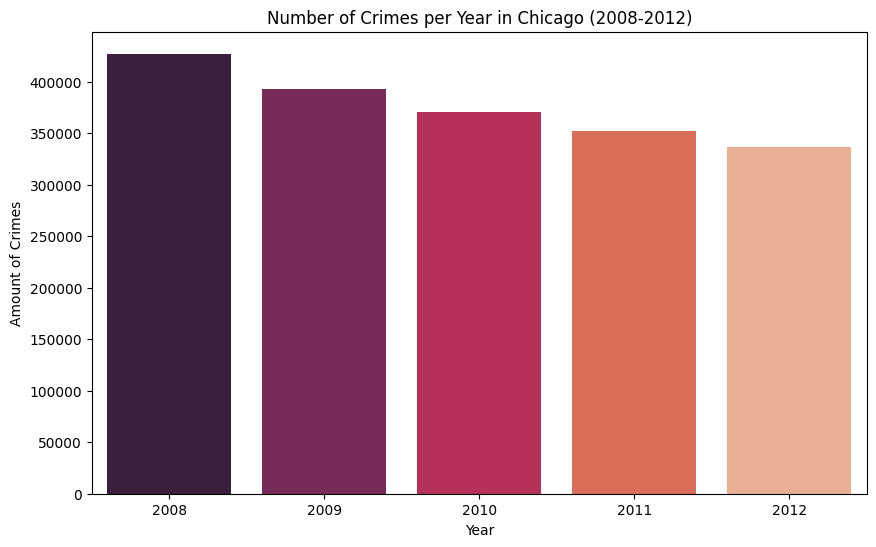

In [174]:
plt.figure(figsize=(10,6))
sns.barplot(data=crimes_per_year_df, x="Year", y="Amount of Crimes", palette="rocket")
plt.title("Number of Crimes per Year in Chicago (2008-2012)")
plt.xlabel("Year")
plt.ylabel("Amount of Crimes")
plt.show()

**3.3** Has the number of recorded crimes increased, decreased or remained stable over said period?

**Svar: While the overall crime rate in Chicago remained high between 2008-2012. We can see a consisting downward trend each year between 2008-2012.**


**3.4** By how many percentage points has the crime rate increased/decreased over this period? 

Hint: You only need to compare the number of crime records from 2008 with the number of crime records from 2012.

**Svar: Decrease by 21.26 (kod nedan)**

In [175]:
crimes_2008 = crimes_per_year_df[crimes_per_year_df["Year"] == 2008]["Amount of Crimes"].values[0]
crimes_2012 = crimes_per_year_df[crimes_per_year_df["Year"] == 2012]["Amount of Crimes"].values[0]
percentage_point_change = ((crimes_2012 - crimes_2008) / crimes_2008) * 100
print(f"The percentage point change in crimes in Chicago from 2008 to 2012 is approximately {round(percentage_point_change, 2)}%")

The percentage point change in crimes in Chicago from 2008 to 2012 is approximately -21.26%


**3.5** Which primary crime types have increasing crime rates, and which ones have decreasing crime rates, when comparing 2008 to 2012?

**Svar: In the dataframe I created below we can see each Primary crime visualized for both 2008 and 2012 and the change between thoose years in the column "Change" sorted from increasing to decreasing. (kod nedan)**

In [176]:
mask_2008 = chicago_crime_2008_to_2012_df["Year"] == 2008
mask_2012 = chicago_crime_2008_to_2012_df["Year"] == 2012

type_crime_2008 = chicago_crime_2008_to_2012_df[mask_2008]["Primary Type"].value_counts()
type_crime_2012 = chicago_crime_2008_to_2012_df[mask_2012]["Primary Type"].value_counts()

comparison_chicago_2008_and_2012_df = pd.DataFrame({
    "2008" : type_crime_2008,
    "2012" : type_crime_2012
})

comparison_chicago_2008_and_2012_df["Change"] = comparison_chicago_2008_and_2012_df["2012"] - comparison_chicago_2008_and_2012_df["2008"]

comparison_chicago_2008_and_2012_df = comparison_chicago_2008_and_2012_df.sort_values(by="Change", ascending=False)

In [177]:
comparison_chicago_2008_and_2012_df

,2008,2012,Change
Primary Type,,,
INTERFERENCE WITH PUBLIC OFFICER,580,1228,648
WEAPONS VIOLATION,3877,3907,30
CRIMINAL SEXUAL ASSAULT,66,90,24
STALKING,190,207,17
OBSCENITY,13,26,13
PUBLIC INDECENCY,4,17,13
HOMICIDE,513,515,2
OTHER NARCOTIC VIOLATION,12,6,-6
PUBLIC PEACE VIOLATION,3013,3007,-6


# 4 - Chicago Police Departement performance assesment

**4.1** How many recorded crimes have in total led to an arrest? What's the corresponding arrest percentage?

**Svar: 508427 recorded crimes led to an arrest from 2008-2012. With the corresponding arrest percent of 27.058% (kod nedan)**

In [178]:
total_arrests = chicago_crime_2008_to_2012_df["Arrest"].value_counts()[True]
print(f"Total recorded crimes that led to an arrest between 2008 to 2012: {total_arrests}")

Total recorded crimes that led to an arrest between 2008 to 2012: 508427


In [179]:
arrest_percent = chicago_crime_2008_to_2012_df["Arrest"].mean()*100
print(f"The corresponding arrest rate in Chicago 2008-2012 is {arrest_percent.round(3)}% ")

The corresponding arrest rate in Chicago 2008-2012 is 27.058% 


**4.2** Has the arrest rate percentage been increasing, decreasing or remained stable over these years?

**Svar: Arrest % rose from 2008 and had its peak 2009. From 2009-2010 it decreased a bit and has remained pretty stable until 2012. (Kod och plot nedan)**

In [180]:
arrest_percent_per_year = (chicago_crime_2008_to_2012_df.groupby("Year")["Arrest"].mean()*100).reset_index(name="Arrest %")

In [181]:
arrest_percent_per_year

,Year,Arrest %
0,2008,25.754895
1,2009,28.215506
2,2010,27.137772
3,2011,27.355594
4,2012,26.960136


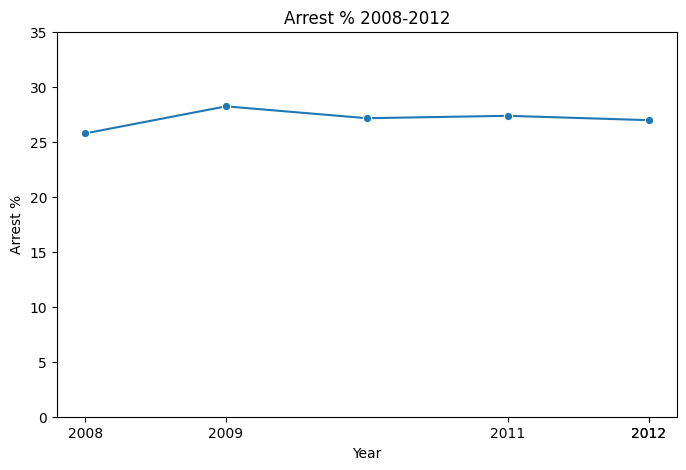

In [182]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=arrest_percent_per_year,
    x = "Year",
    y = "Arrest %",
    marker = "o"
)
plt.title("Arrest % 2008-2012")
plt.ylabel("Arrest %")
plt.xlabel("Year")
plt.xticks([2008, 2009, 2012, 2011, 2012])
plt.ylim(0,35)
plt.show()

**4.3** For the Year 2011, which month has the highest arrest percentage?

**Svar: The month with the highest arrest percentage in Chicago 2011 was: March with an arrest rate of 29.3025% (kod nedan)**

In [183]:
mask_2011 = chicago_crime_2008_to_2012_df["Year"] == 2011
arrest_2011_df = chicago_crime_2008_to_2012_df[mask_2011]

In [184]:
arrest_percentage_2011_df = (arrest_2011_df.groupby("Month_name")["Arrest"].mean()*100).reset_index(name="Arrest %").sort_values(by="Arrest %",ascending=False).reset_index(drop=True)

In [185]:
arrest_percentage_2011_df

,Month_name,Arrest %
0,March,29.302536
1,February,29.202068
2,January,28.860416
3,August,27.736376
4,September,27.679824
5,April,27.172196
6,December,26.958645
7,November,26.922382
8,July,26.640613
9,June,26.493876


In [186]:
highest_arrest_index = arrest_percentage_2011_df["Arrest %"].idxmax()
highest_arrest_month = arrest_percentage_2011_df.loc[highest_arrest_index, "Month_name"]
highest_arrest_percent = arrest_percentage_2011_df.loc[highest_arrest_index, "Arrest %"]
print(f" The month with the highest arrest percentage in Chicago 2011 was: {highest_arrest_month} with an arrest rate of {highest_arrest_percent.round(4)}%")

 The month with the highest arrest percentage in Chicago 2011 was: March with an arrest rate of 29.3025%


**4.4** For the same year, and the particular month of you've identified in question 2.3, which primary crime type has the highest number of arrests? (Utgår ifrån att du menar 4.3 och inte 2.3 :)

**Svar: The primary crime with the most arrests in March 2011 in Chicago was: NARCOTICS with 3747 arrests**

In [187]:
march_2011_mask = arrest_2011_df["Month"] == 3
march_2011_df = arrest_2011_df[march_2011_mask]

In [188]:
true_arrests_2011_march_mask = march_2011_df["Arrest"] == True
true_arrests_2011_march_df = march_2011_df[true_arrests_2011_march_mask]

In [189]:
true_arrests_2011_march_df["Primary Type"].value_counts().reset_index(name="Number of Arrests")

,Primary Type,Number of Arrests
0,NARCOTICS,3747
1,BATTERY,1285
2,THEFT,611
3,CRIMINAL TRESPASS,599
4,ASSAULT,440
5,OTHER OFFENSE,243
6,CRIMINAL DAMAGE,236
7,WEAPONS VIOLATION,211
8,PUBLIC PEACE VIOLATION,201
9,PROSTITUTION,201


In [190]:
top_arrested_crime_march_2011 = true_arrests_2011_march_df["Primary Type"].value_counts().idxmax()
top_arrested_crime_count_2011 = true_arrests_2011_march_df["Primary Type"].value_counts().max()
print(f"The primary crime with the most arrests in March 2011 in Chicago was: {top_arrested_crime_march_2011} with {top_arrested_crime_count_2011} arrests")

The primary crime with the most arrests in March 2011 in Chicago was: NARCOTICS with 3747 arrests


# 5 - Troubles at home

**5.1** How many recorded crimes are domestic?

**Svar: Amount of recorded domestic crimes is: 309845 (kod nedan)**

In [191]:
chicago_crime_2008_to_2012_df["Domestic"].value_counts()

Domestic
False    1569202
True      309845
Name: count, dtype: int64

In [192]:
true_domestic_mask = chicago_crime_2008_to_2012_df["Domestic"] == True
domestic_crimes_2008_to_2012_df = chicago_crime_2008_to_2012_df[true_domestic_mask]
domestic_crimes_2008_to_2012_sum = domestic_crimes_2008_to_2012_df["Domestic"].sum()

print(f"Amount of recorded domestic crimes is: {domestic_crimes_2008_to_2012_sum}")

Amount of recorded domestic crimes is: 309845


**5.2** How many domestic recorded crimes are of the primary type *offense involving children*?

**Svar: Amount of domestic crimes involving children betwwen 2008 and 2012 is: 10983 (Kod nedan)**

In [193]:
offense_involving_children_domestic_mask = domestic_crimes_2008_to_2012_df["Primary Type"] == "OFFENSE INVOLVING CHILDREN"
offense_involving_children_domestic_2008_to_2012_df = domestic_crimes_2008_to_2012_df[offense_involving_children_domestic_mask]


In [194]:
amount_domestic_involving_children = offense_involving_children_domestic_2008_to_2012_df["ID"].nunique()
print(f"Amount of domestic crimes involving children betwwen 2008 and 2012 is: {amount_domestic_involving_children}")

Amount of domestic crimes involving children betwwen 2008 and 2012 is: 10983


**5.3** How much more likely is it that an offense involving children is domestic?

**Svar: 86.14% of offenses involving children are domestic. 13.86% are non domestic. (Chicago 2008-2012) (kod och plot nedan)**

In [195]:
offense_involving_children_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "OFFENSE INVOLVING CHILDREN"
offense_involving_children_df = chicago_crime_2008_to_2012_df[offense_involving_children_mask]


In [196]:
offense_involving_children_count_df = offense_involving_children_df["Domestic"].value_counts().reset_index(name="Count")
offense_involving_children_count_df_relable_plot = offense_involving_children_count_df.replace({True: "Domestic", False: "Non-Domestic"})

In [197]:
offense_involving_children_count_df


,Domestic,Count
0,True,10983
1,False,1767


In [198]:
offense_involving_children_count_df_relable_plot

,Domestic,Count
0,Domestic,10983
1,Non-Domestic,1767


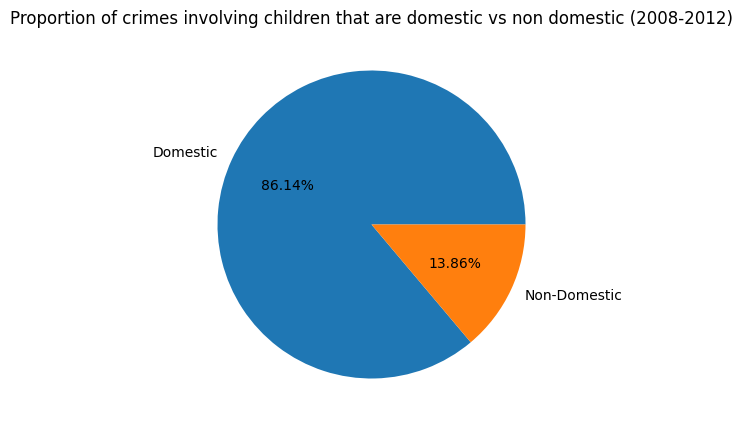

In [199]:
plt.figure(figsize=(8,5))
plt.pie(offense_involving_children_count_df_relable_plot["Count"], labels = offense_involving_children_count_df_relable_plot["Domestic"], autopct="%1.2f%%")
plt.title("Proportion of crimes involving children that are domestic vs non domestic (2008-2012)")
plt.show()

**5.4** What's the worst weekday in terms of number of domestic offenses involving children? How does it compare to the other weekdays?

**Svar: The worst weekday in terms of domestic offenses involving children is Friday. On the plot below you can see how it compares to other weekdays. (kod och plot nedan)**

In [200]:
offense_involving_children_domestic_weekdays_df = offense_involving_children_domestic_2008_to_2012_df["Weekday"].value_counts(sort=False).reset_index(name="Amount of reported crimes")

In [201]:
offense_involving_children_domestic_weekdays_df

,Weekday,Amount of reported crimes
0,Monday,1315
1,Tuesday,1401
2,Wednesday,1378
3,Thursday,1440
4,Friday,2033
5,Saturday,1725
6,Sunday,1691


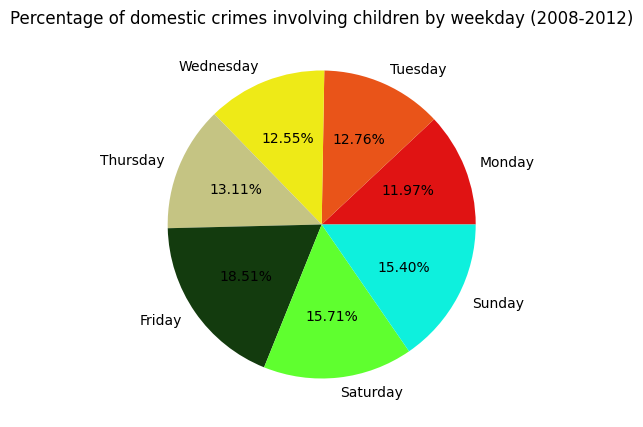

In [202]:
plt.figure(figsize=(8,5))
plt.pie(offense_involving_children_domestic_weekdays_df["Amount of reported crimes"], labels = offense_involving_children_domestic_weekdays_df["Weekday"], autopct="%1.2f%%", colors = ["#e01313", "#e95419", "#eeea17",
          "#c5c483", "#133b0e", "#5fff2f", "#0ef0dd"])
plt.title("Percentage of domestic crimes involving children by weekday (2008-2012)")
plt.show()

**5.5** What's the distribution, in terms of number of records, for domestic crimes of sexual character that involves children? What's the arrest rate (%) for each? 

**Svar: Total amount of domestic crimes involving children between 2008-2012 of sexual character is: 1107  The distribution of each crime in terms of number of records and arrest% can be seen in the dataframes and plots Ive created below. (kod och plot nedan)**



In [203]:
sexual_primary_types = ["OFFENSE INVOLVING CHILDREN", "SEX OFFENSE", "PROSTITUTION", "CRIMINAL SEXUAL ASSAULT", "CRIM SEXUAL ASSAULT"]
is_primary_match = domestic_crimes_2008_to_2012_df["Primary Type"].isin(sexual_primary_types)

sexual_keywords = "SEX|FOND|MOLEST|PORN|PROSTITU"
is_sexual_keyword = domestic_crimes_2008_to_2012_df["Description"].str.contains(sexual_keywords, case=False, na=False)
child_keywords = "CHILD|KID|MINOR"
is_child_keyword = domestic_crimes_2008_to_2012_df["Description"].str.contains(child_keywords, case=False, na=False)

domestic_crimes_sexual_character_involving_children_df = domestic_crimes_2008_to_2012_df[is_primary_match & is_sexual_keyword & is_child_keyword]

In [204]:
domestic_crimes_sexual_character_involving_children_df.head()

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,Month,Month_name,Day,Hour,Weekday,Date only,Month_day,Time_of_day
3099,12992494,JG164139,2012-12-28 00:01:00,114XX S SPAULDING AVE,1544,SEX OFFENSE,SEXUAL EXPLOITATION OF A CHILD,RESIDENCE,False,True,...,-87.703034,"(41.685426134, -87.703034008)",12,December,28,0,Friday,2012-12-28,12-28,Nighttime
5643,13235167,JG453368,2012-12-24 00:00:00,053XX S DREXEL AVE,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,RESIDENCE,False,True,...,-87.603891,"(41.798088927, -87.603890577)",12,December,24,0,Monday,2012-12-24,12-24,Nighttime
7907,12012671,JD189454,2012-12-21 00:00:00,046XX S CALIFORNIA AVE,1754,OFFENSE INVOLVING CHILDREN,AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY M...,OTHER (SPECIFY),False,True,...,-87.694241,"(41.809467029, -87.69424134)",12,December,21,0,Friday,2012-12-21,12-21,Nighttime
8587,9914703,HY104119,2012-12-20 08:00:00,018XX S LAWNDALE AVE,1753,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,APARTMENT,False,True,...,-87.717588,"(41.855876672, -87.717587712)",12,December,20,8,Thursday,2012-12-20,12-20,Daytime
8731,9003078,HW149983,2012-12-20 00:01:00,065XX S CAMPBELL AVE,1753,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,True,True,...,-87.685962,"(41.774922222, -87.685961766)",12,December,20,0,Thursday,2012-12-20,12-20,Nighttime


In [205]:
#Noterade att vissa descriptions har samma mening men har olika namn jag mergar därför ihop dem här för att få renare översikt.

mapping = {
    "AGGRAVATED SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER": "AGG SEX ASSLT OF CHILD FAM MBR",
    "AGG SEX ASSLT OF CHILD FAM MBR": "AGG SEX ASSLT OF CHILD FAM MBR",
    "SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER": "SEX ASSLT OF CHILD BY FAM MBR",
    "SEX ASSLT OF CHILD BY FAM MBR": "SEX ASSLT OF CHILD BY FAM MBR"
}

domestic_crimes_sexual_character_involving_children_df["Description"] = domestic_crimes_sexual_character_involving_children_df["Description"].replace(mapping)

In [206]:
arrest_count_children_domestic_sexual_character_df = (domestic_crimes_sexual_character_involving_children_df.groupby("Description")["Arrest"].mean()*100).reset_index(name="Arrest %")

In [207]:
amount_domestic_crimes_sexual_character_involving_children_df = domestic_crimes_sexual_character_involving_children_df["Description"].value_counts().reset_index(name="Amount of reports")

In [208]:
amount_domestic_crimes_sexual_character_involving_children_df

,Description,Amount of reports
0,AGG SEX ASSLT OF CHILD FAM MBR,668
1,SEX ASSLT OF CHILD BY FAM MBR,360
2,SEXUAL EXPLOITATION OF A CHILD,58
3,CHILD PORNOGRAPHY,21


In [209]:
print(f"Total amount of domestic crimes involving children between 2008-2012 of sexual character is: {amount_domestic_crimes_sexual_character_involving_children_df["Amount of reports"].sum()}")

Total amount of domestic crimes involving children between 2008-2012 of sexual character is: 1107


In [210]:

arrest_count_children_domestic_sexual_character_df

,Description,Arrest %
0,AGG SEX ASSLT OF CHILD FAM MBR,29.790419
1,CHILD PORNOGRAPHY,19.047619
2,SEX ASSLT OF CHILD BY FAM MBR,22.222222
3,SEXUAL EXPLOITATION OF A CHILD,17.241379


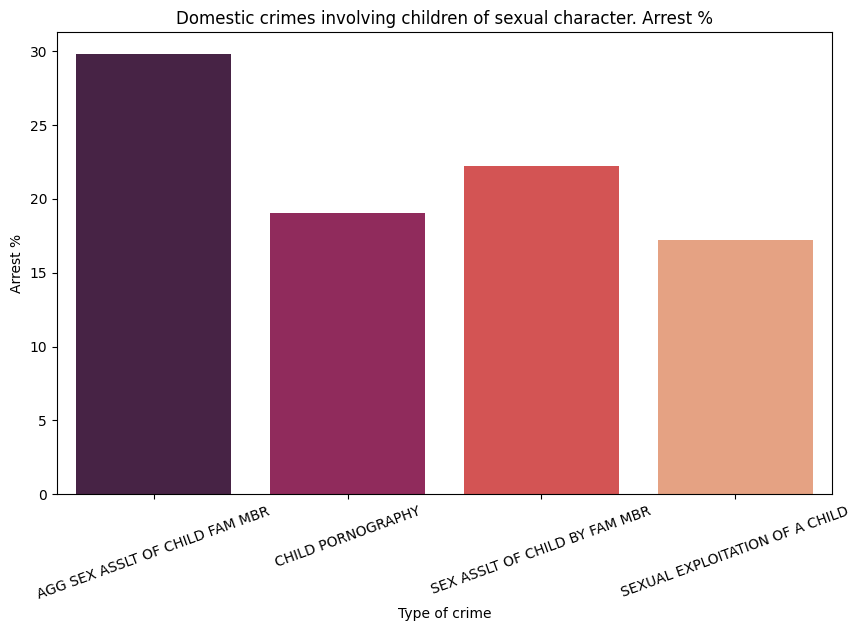

In [211]:
plt.figure(figsize=(10,6))
sns.barplot(data=arrest_count_children_domestic_sexual_character_df, x="Description", y="Arrest %", palette="rocket")
plt.title("Domestic crimes involving children of sexual character. Arrest %")
plt.xlabel("Type of crime")
plt.ylabel("Arrest %")
plt.xticks(rotation = 20
           )
plt.show()

**5.6** What period of the day does the specific kind of (domestic) offense against children, with the most recorded arrests, tend do occur? How does it look for all weekdays individually?
        Can you find certain periods of the week that are especially bad? 

    Note: the details of this question is up to you to interpret

    **Svar: Around 00:00 each day there is a noticable spike in recorded arrests per day. However looking at specific times in this case could be misleading.Ive come across plenty of records in the Chicago Crime dataset that misses the exact timestamp and it appears that the system defaults these cases to 00:00.Its important to keep this in mind.To adress this Ive created two plots.One that focuses on the time for each weekday and one plot that focuses on the totals for each weekday. We can see that Fridays have by far,the highest totals, and weekends overall have slightly higher total than rest of the week, except for Tuesdays that stands out as an anomaly compared to Monday-Thursday.**

In [212]:
Agg_sex_assault_child_fam_memb_mask = domestic_crimes_sexual_character_involving_children_df["Description"] == "AGG SEX ASSLT OF CHILD FAM MBR"
agg_sex_assault_child_fam_memb_df = domestic_crimes_sexual_character_involving_children_df[Agg_sex_assault_child_fam_memb_mask]

In [213]:
agg_sex_assault_child_fam_memb_df.head(10)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,Month,Month_name,Day,Hour,Weekday,Date only,Month_day,Time_of_day
5643,13235167,JG453368,2012-12-24 00:00:00,053XX S DREXEL AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,True,...,-87.603891,"(41.798088927, -87.603890577)",12,December,24,0,Monday,2012-12-24,12-24,Nighttime
7907,12012671,JD189454,2012-12-21 00:00:00,046XX S CALIFORNIA AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,OTHER (SPECIFY),False,True,...,-87.694241,"(41.809467029, -87.69424134)",12,December,21,0,Friday,2012-12-21,12-21,Nighttime
8750,11540704,JB560188,2012-12-19 23:59:00,006XX E 89TH PL,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,True,True,...,NaN,NaN,12,December,19,23,Wednesday,2012-12-19,12-19,Nighttime
9605,9559785,HX210852,2012-12-19 00:01:00,006XX E 89TH PL,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,True,True,...,-87.608533,"(41.73203018, -87.6085329)",12,December,19,0,Wednesday,2012-12-19,12-19,Nighttime
9613,9665904,HX316083,2012-12-19 00:00:00,017XX N KEYSTONE AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,APARTMENT,True,True,...,-87.727628,"(41.912200843, -87.727627601)",12,December,19,0,Wednesday,2012-12-19,12-19,Nighttime
10474,12900566,JF484031,2012-12-18 00:00:00,103XX S TRUMBULL AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,True,...,NaN,NaN,12,December,18,0,Tuesday,2012-12-18,12-18,Nighttime
14704,12797192,JF359848,2012-12-13 00:01:00,009XX N LOREL AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,APARTMENT,True,True,...,NaN,NaN,12,December,13,0,Thursday,2012-12-13,12-13,Nighttime
17294,11203818,JB115830,2012-12-10 00:01:00,077XX S KARLOV AVE,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,True,True,...,-87.723821,"(41.752137538, -87.723820826)",12,December,10,0,Monday,2012-12-10,12-10,Nighttime
17296,12935045,JF524487,2012-12-10 00:01:00,107XX S AVENUE F,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,APARTMENT,True,True,...,NaN,NaN,12,December,10,0,Monday,2012-12-10,12-10,Nighttime
19253,8934944,HV606908,2012-12-07 15:30:00,008XX E 90TH PL,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,True,...,-87.603933,"(41.7302749, -87.603932909)",12,December,7,15,Friday,2012-12-07,12-07,Daytime


In [214]:
agg_sex_assault_child_fam_memb_weekday_df = (agg_sex_assault_child_fam_memb_df.groupby(["Weekday", "Hour"]).size().reset_index(name="Amount of reports"))

In [215]:
agg_sex_assault_child_fam_memb_weekday_df

,Weekday,Hour,Amount of reports
0,Monday,0,46
1,Monday,1,4
2,Monday,2,0
3,Monday,3,3
4,Monday,4,1
...,...,...,...
163,Sunday,19,1
164,Sunday,20,3
165,Sunday,21,1
166,Sunday,22,4


In [216]:
agg_sex_assault_child_fam_memb_weekday_heatmap_pivot = agg_sex_assault_child_fam_memb_weekday_df.pivot(
    index = "Weekday",
    columns = "Hour",
    values = "Amount of reports"
).fillna(0)

In [217]:
agg_sex_assault_child_fam_memb_weekday_heatmap_pivot

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Weekday,,,,,,,,,,,,,,,,,,,,,
Monday,46,4,0,3,1,1,2,1,2,2,...,1,0,1,4,1,4,1,2,1,2
Tuesday,58,1,1,0,0,0,2,3,4,1,...,6,2,2,0,0,0,2,1,2,1
Wednesday,48,0,3,0,0,0,1,2,4,0,...,2,5,4,2,2,1,0,3,1,4
Thursday,40,4,0,0,0,0,0,2,7,3,...,1,3,0,1,4,1,4,1,2,1
Friday,64,1,3,0,0,0,0,4,2,2,...,3,8,2,2,8,2,4,3,5,2
Saturday,45,5,2,2,0,1,0,0,3,4,...,0,2,1,6,4,3,4,3,3,0
Sunday,49,1,2,1,2,0,2,5,1,1,...,2,1,1,1,3,1,3,1,4,1


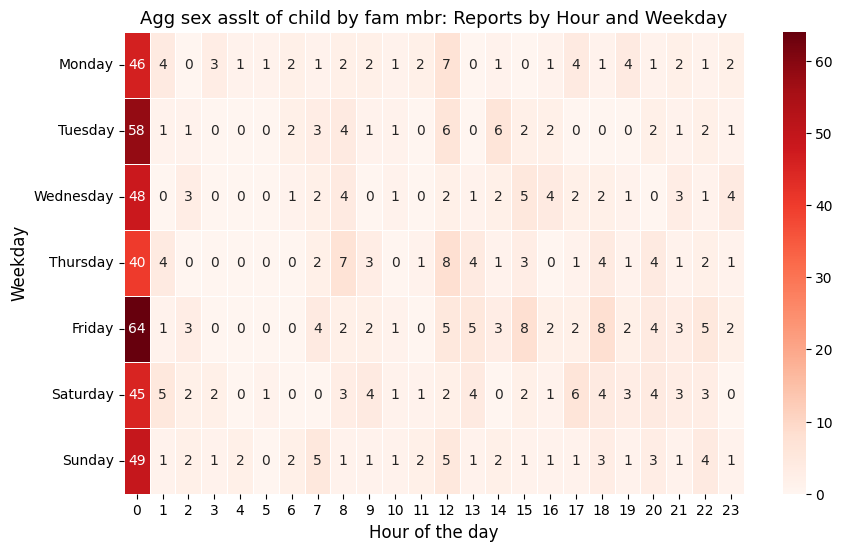

In [218]:
plt.figure(figsize=(10,6))
sns.heatmap(
    agg_sex_assault_child_fam_memb_weekday_heatmap_pivot,
    cmap="Reds",
    annot=True,
    fmt=".0f",
    linewidths=0.5
    
)
plt.title("Agg sex asslt of child by fam mbr: Reports by Hour and Weekday", fontsize=13)
plt.xlabel("Hour of the day", fontsize = 12)
plt.ylabel("Weekday", fontsize=12)
plt.show()

In [219]:
agg_sex_assault_child_fam_memb_weekday_amount = agg_sex_assault_child_fam_memb_df["Weekday"].value_counts().reset_index(name="Amount of reports")

In [220]:
agg_sex_assault_child_fam_memb_weekday_amount

,Weekday,Amount of reports
0,Friday,126
1,Saturday,96
2,Tuesday,93
3,Sunday,91
4,Monday,89
5,Thursday,87
6,Wednesday,86


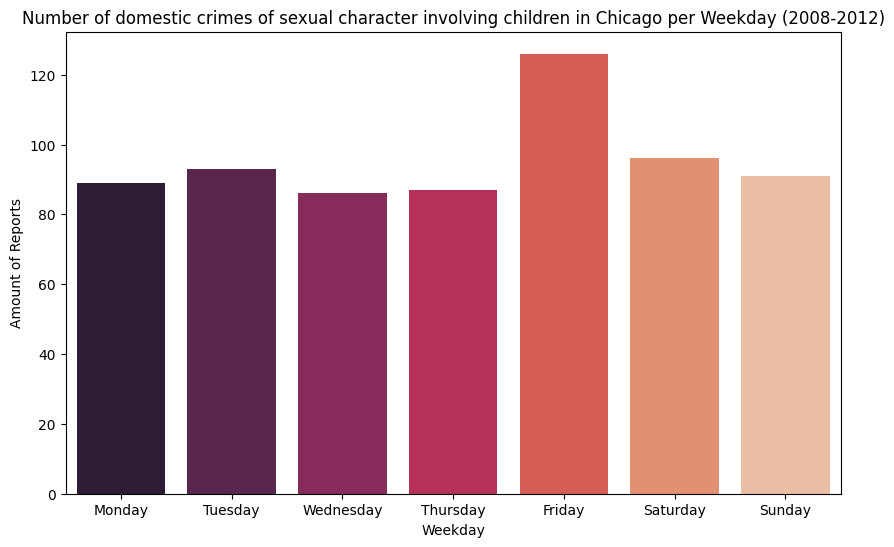

In [221]:
plt.figure(figsize=(10,6))
sns.barplot(data=agg_sex_assault_child_fam_memb_weekday_amount, x="Weekday", y="Amount of reports", palette="rocket")
plt.title("Number of domestic crimes of sexual character involving children in Chicago per Weekday (2008-2012)")
plt.xlabel("Weekday")
plt.ylabel("Amount of Reports")
plt.show()

**5.7** Looking at any given year as a whole, what's the worst period in terms of domestic number of offenses involving children? Can you find any trends? Does the trend seem to be consistent for every other year? 

    Note: the details of this question is up to you to interpret

# 6 - Bad Boys Bad Boys whatcha gonna do

**6.1** In general, what weekday is a crime most likely to occur? Which day is the safest?

**Svar:In general, the weekday that a crime most likely occurs is: Friday.**
**In general the safest day of the week, the day where a crime less likely occurs is: Sunday (Kod nedan)**

In [222]:
weekday_counts = chicago_crime_2008_to_2012_df["Weekday"].value_counts(sort=False)

most_crimes_weekday = weekday_counts.idxmax()

least_crimes_weekday = weekday_counts.idxmin()




In [223]:
weekday_counts

Weekday
Monday       263030
Tuesday      271316
Wednesday    273642
Thursday     269181
Friday       284130
Saturday     266355
Sunday       251393
Name: count, dtype: int64

In [224]:
print(f"In general, the weekday that a crime most likely occurs is: {most_crimes_weekday}")
print(f"In general the safest day of the week, the day where a crime less likely occurs is: {least_crimes_weekday} ")

In general, the weekday that a crime most likely occurs is: Friday
In general the safest day of the week, the day where a crime less likely occurs is: Sunday 


**6.2** Which is the most unsafe weekday for you if you'd like to avoid the following:

a) getting your phone stolen by sneaky pickpockets (THEFT)

b) having your handbag forcibly pulled away (ROBBERY) 

c) getting jumped in an alley (ASSAULT)
**Svar**
***a) The most unsafe weekday for getting your phone stolen by sneaky pickpockets is: Friday***
***b) The most unsafe weekday for having your handbag forcibly pulled away is: Friday***
***c) The most unsafe weekday for getting jumped in an alley is: Wednesday*** ***(KOD NEDAN)***

In [225]:
#a

theft_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "THEFT"
chicago_crime_2008_to_2012_theft_df = chicago_crime_2008_to_2012_df[theft_mask]
theft_weekday_count = chicago_crime_2008_to_2012_theft_df["Weekday"].value_counts()
most_likely_weekday_theft = theft_weekday_count.idxmax()
print(f"a) The most unsafe weekday for getting your phone stolen by sneaky pickpockets is: {most_likely_weekday_theft} ")

#b
robbery_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "ROBBERY"
chicago_crime_2008_to_2012_robbery_df = chicago_crime_2008_to_2012_df[robbery_mask]
robbery_weekday_count = chicago_crime_2008_to_2012_robbery_df["Weekday"].value_counts()
most_likely_weekday_robbery = robbery_weekday_count.idxmax()
print(f"b) The most unsafe weekday for having your handbag forcibly pulled away is: {most_likely_weekday_robbery}")

#c
assault_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "ASSAULT"
chicago_crime_2008_to_2012_assault_df = chicago_crime_2008_to_2012_df[assault_mask]
assault_weekday_count = chicago_crime_2008_to_2012_assault_df["Weekday"].value_counts()
most_likely_weekday_assault = assault_weekday_count.idxmax()
print(f"c) The most unsafe weekday for getting jumped in an alley is: {most_likely_weekday_assault}")


a) The most unsafe weekday for getting your phone stolen by sneaky pickpockets is: Friday 
b) The most unsafe weekday for having your handbag forcibly pulled away is: Friday
c) The most unsafe weekday for getting jumped in an alley is: Wednesday


**6.3** Which are the worst 10 dates (most recorded crimes) of 2008? Does this trend hold for the other years?

***Svar: I have plotted the 10 worst dates below. I have also written code that checks how many times theese dates occur in the top 10 for all the years and written a warning to the Chicago Police to increase boots on the ground on theese dates.***

In [226]:
chicago_crime_2008_df = chicago_crime_2008_to_2012_df[mask_2008]

In [227]:
chicago_crime_2008_worst10_df = chicago_crime_2008_df["Date only"].value_counts().head(10).reset_index(name="Amount of crime")

In [228]:
chicago_crime_2008_worst10_df

,Date only,Amount of crime
0,2008-01-01,1836
1,2008-08-01,1531
2,2008-11-01,1480
3,2008-09-01,1469
4,2008-10-10,1453
5,2008-05-01,1450
6,2008-10-31,1444
7,2008-08-22,1440
8,2008-06-01,1438
9,2008-08-15,1436


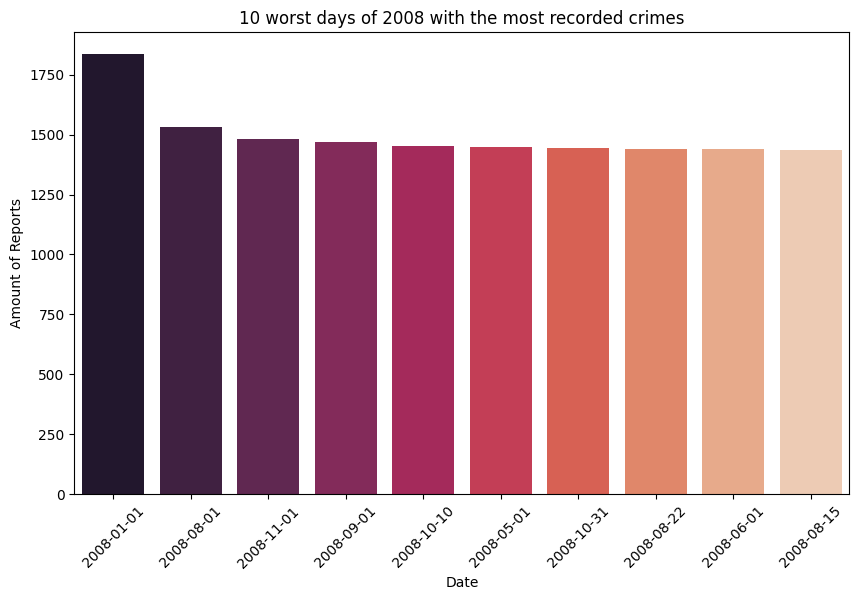

In [229]:
plt.figure(figsize=(10,6))
sns.barplot(data=chicago_crime_2008_worst10_df, x="Date only", y="Amount of crime", palette="rocket")
plt.title("10 worst days of 2008 with the most recorded crimes")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.ylabel("Amount of Reports")
plt.show()

In [230]:
worst_10_per_year = (chicago_crime_2008_to_2012_df.groupby("Year")["Date only"].value_counts().groupby(level=0).head(10))
print(worst_10_per_year)

Year  Date only 
2008  2008-01-01    1836
      2008-08-01    1531
      2008-11-01    1480
      2008-09-01    1469
      2008-10-10    1453
      2008-05-01    1450
      2008-10-31    1444
      2008-08-22    1440
      2008-06-01    1438
      2008-08-15    1436
2009  2009-01-01    1846
      2009-05-01    1355
      2009-08-01    1344
      2009-07-01    1326
      2009-06-01    1308
      2009-08-18    1308
      2009-06-12    1304
      2009-09-11    1286
      2009-06-27    1273
      2009-04-17    1269
2010  2010-01-01    1482
      2010-06-01    1307
      2010-04-01    1265
      2010-07-01    1260
      2010-05-05    1257
      2010-04-15    1256
      2010-10-01    1242
      2010-09-01    1234
      2010-06-10    1232
      2010-05-14    1213
2011  2011-01-01    1574
      2011-08-01    1241
      2011-06-01    1222
      2011-11-01    1206
      2011-07-15    1189
      2011-09-01    1186
      2011-06-02    1178
      2011-06-17    1177
      2011-05-13    1174
      20

In [231]:
#Vi kan se ovan att det finns en tydlig trend varje år att datumet Y/01-01 förekommer högst upp på listan. 
# Jag vill dock se hur många gånger ett specifikt datum återkommer i top10 mellan 2008-2012 så att vi kan förvarna Chicago police dept. om detta. 

In [232]:
worst_10_month_day_all_years = []

for year in range(2008,2013):
    year_df = chicago_crime_2008_to_2012_df[chicago_crime_2008_to_2012_df["Year"] == year]
    worst_10 = year_df["Month_day"].value_counts().head(10).index
    worst_10_month_day_all_years.extend(worst_10)

In [233]:
worst_10_counts = pd.Series(worst_10_month_day_all_years).value_counts()

for date, count in worst_10_counts.items():
    if count > 1:
        print(f"Heads up to the Chicago Police dep. You should increase boots on the ground on {date}. This date occurs {count} times in the top 10 worst dates between 2008-2012")


Heads up to the Chicago Police dep. You should increase boots on the ground on 01-01. This date occurs 5 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the ground on 06-01. This date occurs 5 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the ground on 08-01. This date occurs 4 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the ground on 09-01. This date occurs 4 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the ground on 07-01. This date occurs 3 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the ground on 11-01. This date occurs 2 times in the top 10 worst dates between 2008-2012
Heads up to the Chicago Police dep. You should increase boots on the g

**6.4** From the perspective of total number of crime records, which are the Top 10 primary crime types? Which are the Bottom 10? 

Consider this question for the years 2008-2012 as a whole. 

***Svar: I have created two dataframes one for top 10 and one for bottom 10. I have also plotted them below.***

In [234]:
top_10_primary_crimes_df = chicago_crime_2008_to_2012_df["Primary Type"].value_counts().head(10).reset_index(name="Amount of reports")

In [235]:
top_10_primary_crimes_df

,Primary Type,Amount of reports
0,THEFT,396789
1,BATTERY,329385
2,CRIMINAL DAMAGE,214408
3,NARCOTICS,207540
4,BURGLARY,128871
5,OTHER OFFENSE,111876
6,ASSAULT,110157
7,MOTOR VEHICLE THEFT,89270
8,ROBBERY,74426
9,DECEPTIVE PRACTICE,67966


In [236]:
bottom_10_primary_crimes_df = chicago_crime_2008_to_2012_df["Primary Type"].value_counts().tail(10).sort_values(ascending= True).reset_index(name="Amount of reports")

In [237]:
bottom_10_primary_crimes_df

,Primary Type,Amount of reports
0,HUMAN TRAFFICKING,2
1,OTHER NARCOTIC VIOLATION,36
2,PUBLIC INDECENCY,51
3,OBSCENITY,134
4,CRIMINAL SEXUAL ASSAULT,371
5,STALKING,935
6,INTIMIDATION,1017
7,KIDNAPPING,1467
8,HOMICIDE,2365
9,ARSON,2755


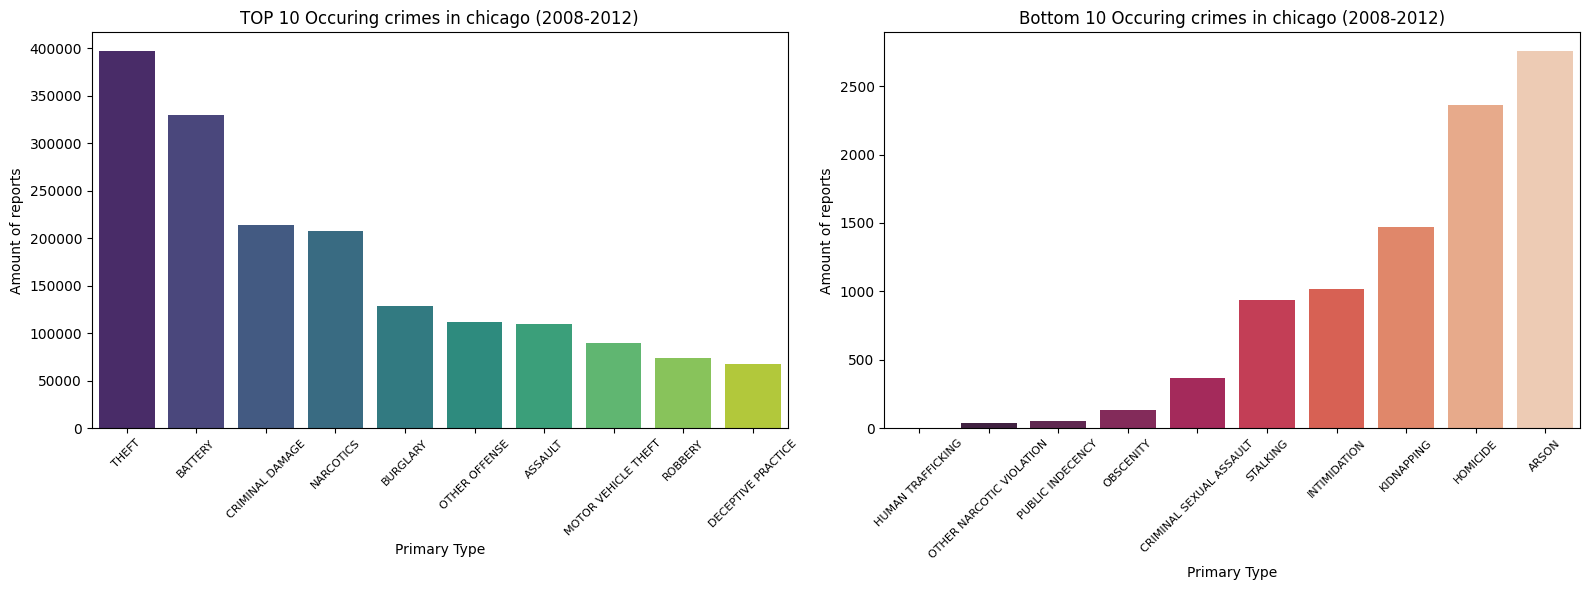

In [238]:
fig, axes = plt.subplots(1,2,figsize=(16,6))

sns.barplot(
    ax=axes[0],
    data=top_10_primary_crimes_df,
    x="Primary Type",
    y="Amount of reports",
    palette="viridis")
axes[0].set_title("TOP 10 Occuring crimes in chicago (2008-2012)")
axes[0].set_xlabel("Primary Type")
axes[0].set_ylabel("Amount of reports")
axes[0].tick_params(axis="x", rotation = 45,labelsize = 8)

sns.barplot(
    ax=axes[1],
    data=bottom_10_primary_crimes_df,
    x="Primary Type",
    y="Amount of reports",
    palette="rocket")
axes[1].set_title("Bottom 10 Occuring crimes in chicago (2008-2012)")
axes[1].set_xlabel("Primary Type")
axes[1].set_ylabel("Amount of reports")
axes[1].tick_params(axis="x", rotation = 45, labelsize = 8)


plt.tight_layout()
plt.show()

**6.5** For all those crime categories you identified in 6.4, how does their distribution instead look per year - rather than the full 2008-2012 period as a whole?

***Svar: I have plotted two plots down below. One for top 10 and one for bottom 10.***
***On the plot below you can see the distribution for all theese primary type of crimes by year and how the trend goes.***
***The bottom 10 crimes on the other hand has remained more steady and in some cases like homicide, criminal sexual assault the amount of reports have become higher since 2008.***

In [239]:
top_10p_mask = chicago_crime_2008_to_2012_df["Primary Type"].isin(top_10_primary_crimes_df["Primary Type"])
bottom_10p_mask = chicago_crime_2008_to_2012_df["Primary Type"].isin(bottom_10_primary_crimes_df["Primary Type"])

In [240]:
chicago_crime_2008_to_2012_top10_primary_df = chicago_crime_2008_to_2012_df[top_10p_mask]
chicago_crime_2008_to_2012_bottom10_primary_df = chicago_crime_2008_to_2012_df[bottom_10p_mask]

In [241]:
chicago_crime_2008_to_2012_top10_primary_df = chicago_crime_2008_to_2012_top10_primary_df.groupby("Year")["Primary Type"].value_counts().reset_index(name="Amount of reports")
chicago_crime_2008_to_2012_bottom10_primary_df = chicago_crime_2008_to_2012_bottom10_primary_df.groupby("Year")["Primary Type"].value_counts().reset_index(name="Amount of reports")

In [242]:
fig = px.line(
    chicago_crime_2008_to_2012_top10_primary_df,
    x="Year",
    y="Amount of reports",
    color = "Primary Type",
    markers = True,
    category_orders={"Year": [2008, 2009, 2010, 2011, 2012]},
    title="Top 10 Primary Crimes in Chicago (Distribution each year 2008-2012)")
fig.update_xaxes(type="category")
fig.show()

In [243]:
fig = px.line(
    chicago_crime_2008_to_2012_bottom10_primary_df,
    x="Year",
    y="Amount of reports",
    color = "Primary Type",
    markers = True,
    category_orders={"Year": [2008, 2009, 2010, 2011, 2012]},
    title="Bottom 10 Primary Crimes in Chicago (Distribution each year 2008-2012)")
fig.update_xaxes(type="category")
fig.show()

**6.6** Which primary crime types does the city of Chicago seem to get better at preventing? For which ones is it the opposite, i.e, the situation is getting worse? 

# 7 - Night Stalker

**7.1** Are there more or less crimes reported during daytime, compared with nighttime? Daytime is considered as all hours between 06:00-18:00, nighttime is the rest of the day.

***Svar: There are more reports during daytime than nighttime. (Kod och plot nedan)***

In [244]:
#chicago_crime_2008_to_2012_df["Time_of_day"] = chicago_crime_2008_to_2012_df["Hour"].apply(lambda x: "Daytime" if 6 <= x <= 17 else "Nighttime") 

#OBS: Så fort klockan slår 18:00 blir det nighttime. 

chicago_crime_2008_to_2012_time_of_day_counts_df = chicago_crime_2008_to_2012_df["Time_of_day"].value_counts().reset_index(name="Amount of reports")

In [245]:
chicago_crime_2008_to_2012_time_of_day_counts_df

,Time_of_day,Amount of reports
0,Daytime,962914
1,Nighttime,916133


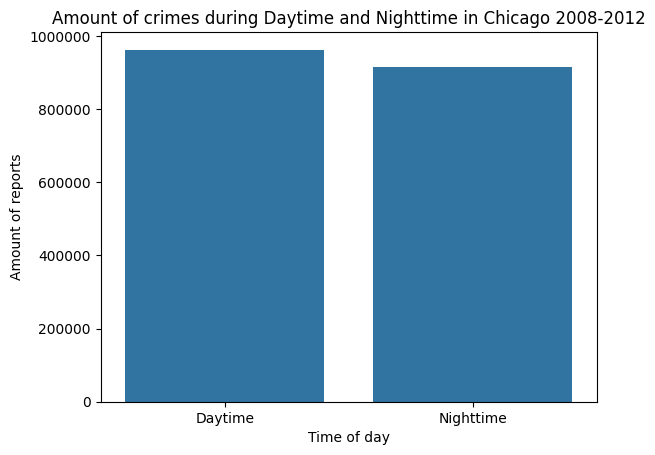

In [246]:
ax = sns.barplot(x='Time_of_day', y='Amount of reports', data=chicago_crime_2008_to_2012_time_of_day_counts_df)
ax.ticklabel_format(style="plain", axis = "y")
ax.set_xlabel("Time of day")
ax.set_title("Amount of crimes during Daytime and Nighttime in Chicago 2008-2012")
plt.show()

**7.2** Are there any specific primary crime types that most often occur during nights? Which ones are they?

***Svar: I have created two Dataframes below. One that shows the amount of reports for Daytime and Nighttime and the change from Daytime to Nighttime. And one that only has the primary crimes types that most often occur during Nighttime and printed them out. (kod nedan)***

In [247]:
daytime_mask = chicago_crime_2008_to_2012_df["Time_of_day"] == "Daytime"
daytime_chicago_crime_2008_to_2012_df = chicago_crime_2008_to_2012_df[daytime_mask]

nighttime_mask = chicago_crime_2008_to_2012_df["Time_of_day"] == "Nighttime"
nighttime_chicago_crime_2008_to_2012_df = chicago_crime_2008_to_2012_df[nighttime_mask]

In [248]:
count_day = daytime_chicago_crime_2008_to_2012_df["Primary Type"].value_counts().reset_index(name="Daytime: Amount of reports")

In [249]:
count_night = nighttime_chicago_crime_2008_to_2012_df["Primary Type"].value_counts().reset_index(name="Nighttime: Amount of reports")

In [250]:
combined = count_day.merge(count_night, on = "Primary Type", how = "outer")
combined = combined.fillna(0).astype({"Daytime: Amount of reports":int, "Nighttime: Amount of reports":int})
combined["Change"] = combined["Nighttime: Amount of reports"] - combined["Daytime: Amount of reports"]

In [251]:
combined

,Primary Type,Daytime: Amount of reports,Nighttime: Amount of reports,Change
0,ARSON,710,2045,1335
1,ASSAULT,63626,46531,-17095
2,BATTERY,149408,179977,30569
3,BURGLARY,84406,44465,-39941
4,CRIM SEXUAL ASSAULT,2263,4766,2503
5,CRIMINAL DAMAGE,89048,125360,36312
6,CRIMINAL SEXUAL ASSAULT,104,267,163
7,CRIMINAL TRESPASS,25910,23527,-2383
8,DECEPTIVE PRACTICE,43698,24268,-19430
9,GAMBLING,1914,2663,749


In [252]:
positive_change_mask = combined["Change"] > 0
Primary_types_positive_change_df = combined[positive_change_mask]

In [253]:
Primary_types_positive_change_df

,Primary Type,Daytime: Amount of reports,Nighttime: Amount of reports,Change
0,ARSON,710,2045,1335
2,BATTERY,149408,179977,30569
4,CRIM SEXUAL ASSAULT,2263,4766,2503
5,CRIMINAL DAMAGE,89048,125360,36312
6,CRIMINAL SEXUAL ASSAULT,104,267,163
9,GAMBLING,1914,2663,749
10,HOMICIDE,850,1515,665
11,HUMAN TRAFFICKING,0,2,2
12,INTERFERENCE WITH PUBLIC OFFICER,1498,2727,1229
15,LIQUOR LAW VIOLATION,731,2856,2125


In [254]:
for crime in Primary_types_positive_change_df["Primary Type"]:
    print(f"{crime} occurs more during Nighttime")

ARSON occurs more during Nighttime
BATTERY occurs more during Nighttime
CRIM SEXUAL ASSAULT occurs more during Nighttime
CRIMINAL DAMAGE occurs more during Nighttime
CRIMINAL SEXUAL ASSAULT occurs more during Nighttime
GAMBLING occurs more during Nighttime
HOMICIDE occurs more during Nighttime
HUMAN TRAFFICKING occurs more during Nighttime
INTERFERENCE WITH PUBLIC OFFICER occurs more during Nighttime
LIQUOR LAW VIOLATION occurs more during Nighttime
MOTOR VEHICLE THEFT occurs more during Nighttime
NARCOTICS occurs more during Nighttime
PROSTITUTION occurs more during Nighttime
PUBLIC INDECENCY occurs more during Nighttime
PUBLIC PEACE VIOLATION occurs more during Nighttime
ROBBERY occurs more during Nighttime
WEAPONS VIOLATION occurs more during Nighttime


**7.3** In general, for each weekday, how many crimes are recorded during daytime and how many during nighttime? What are the trends? Are there any weekdays that stands out somehow?

***Svar: You have shared an answer to this question. However, I have reached a different conclusion. I suspect this is because you counted times like 18:22, 18:03, etc. as Daytime.(I tried that and came to the same conclusion as the answer that was given on this question.) I have considered that as soon as the clock strikes 18:00, it becomes Nighttime, which I believe is the correct interpretation of question 7.1.***

***Anyway.. from Monday to Friday, more crimes occur during the day than at night. On Fridays nighttime crimes increase a bit.***
***Looking at Saturday and Sunday, we can see that more crimes happen at night than during the day. Daytime crimes decreases and nighttime crime increases. We can see this on the plot Ive created below. (Kod och plot nedan)***

In [255]:
night_day_weekday_report_df = chicago_crime_2008_to_2012_df.groupby("Weekday")["Time_of_day"].value_counts(sort=False).reset_index(name="Reports")

In [256]:
night_day_weekday_report_df

,Weekday,Time_of_day,Reports
0,Monday,Daytime,141941
1,Monday,Nighttime,121089
2,Tuesday,Daytime,147483
3,Tuesday,Nighttime,123833
4,Wednesday,Daytime,148847
5,Wednesday,Nighttime,124795
6,Thursday,Daytime,144934
7,Thursday,Nighttime,124247
8,Friday,Daytime,148495
9,Friday,Nighttime,135635


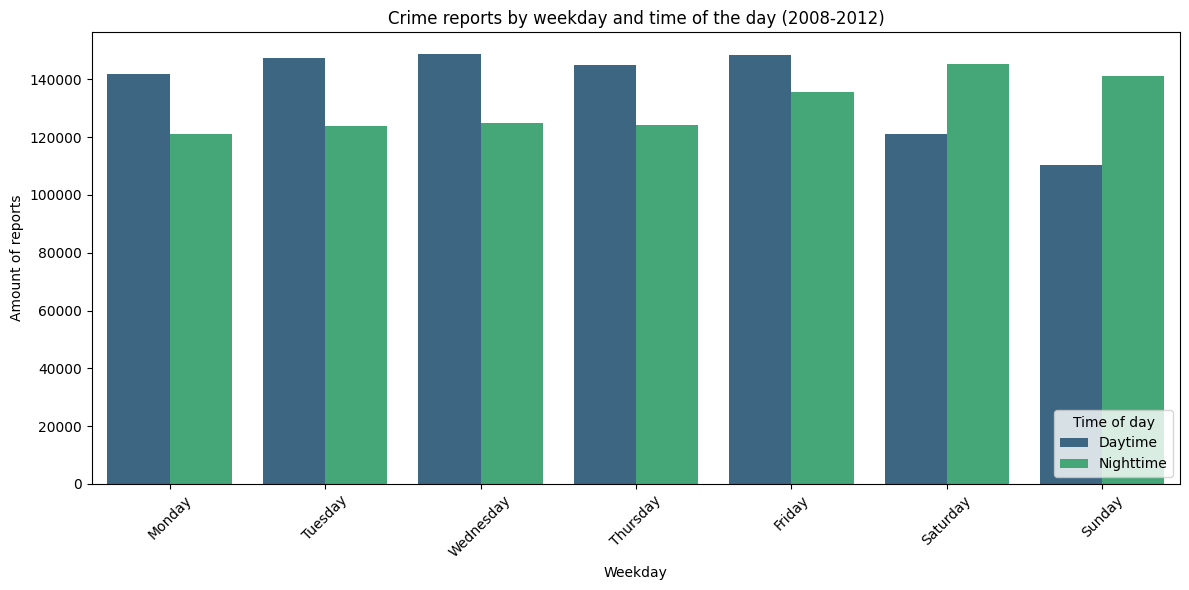

In [257]:
plt.figure(figsize=(12,6))
sns.barplot(data=night_day_weekday_report_df,
x = "Weekday",
y = "Reports",
hue = "Time_of_day",
palette = "viridis")

plt.title("Crime reports by weekday and time of the day (2008-2012)")
plt.xlabel("Weekday")
plt.ylabel("Amount of reports")
plt.xticks(rotation=45)
plt.legend(title="Time of day", loc = "lower right")
plt.tight_layout()
plt.show()

**7.4** Does the trends you've found in 7.3 also hold if you look at each year individually?

**7.5** Are there any weekdays in which Stalking occurs more often during nighttime?

***Svar: No. Stalking happens more often during daytime for each weekday. Altough the gap closes a bit on Saturday and Sunday. (Kod och plot nedan)***

In [258]:
stalking_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "STALKING"
chicago_stalking_2008_to_2012_df = chicago_crime_2008_to_2012_df[stalking_mask]

In [259]:
chicago_stalking_2008_to_2012_week_time_df = chicago_stalking_2008_to_2012_df.groupby("Weekday")["Time_of_day"].value_counts().reset_index(name="Amount")

In [260]:
chicago_stalking_2008_to_2012_week_time_df

,Weekday,Time_of_day,Amount
0,Monday,Daytime,92
1,Monday,Nighttime,59
2,Tuesday,Daytime,100
3,Tuesday,Nighttime,55
4,Wednesday,Daytime,97
5,Wednesday,Nighttime,52
6,Thursday,Daytime,83
7,Thursday,Nighttime,56
8,Friday,Daytime,83
9,Friday,Nighttime,52


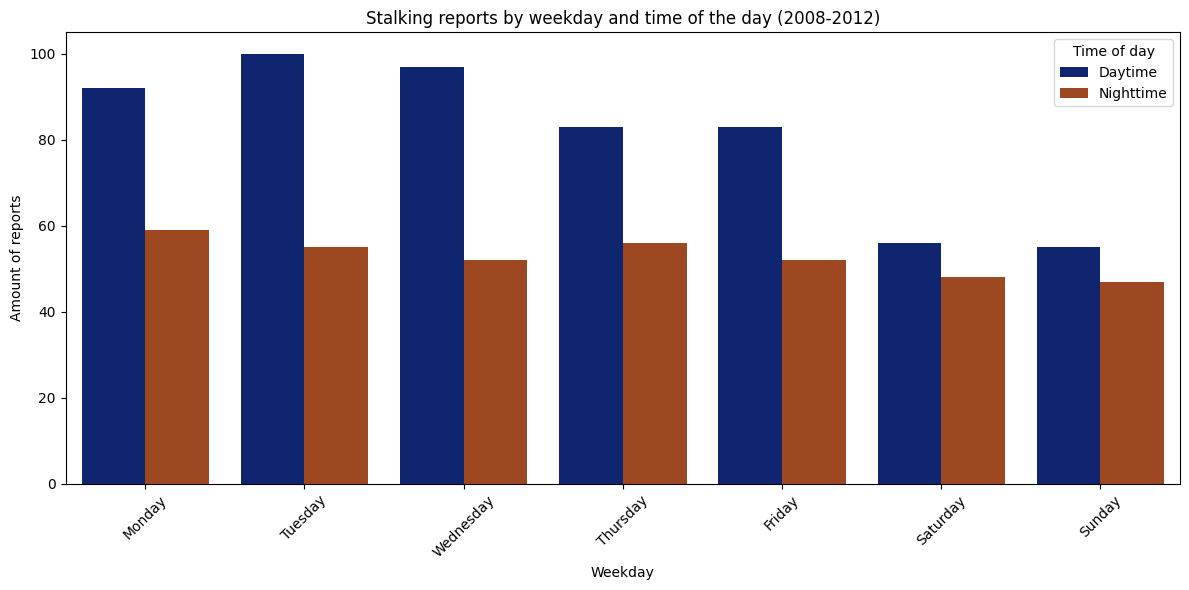

In [261]:
plt.figure(figsize=(12,6))
sns.barplot(data=chicago_stalking_2008_to_2012_week_time_df,
x = "Weekday",
y = "Amount",
hue = "Time_of_day",
palette = "dark")

plt.title("Stalking reports by weekday and time of the day (2008-2012)")
plt.xlabel("Weekday")
plt.ylabel("Amount of reports")
plt.xticks(rotation=45)
plt.legend(title="Time of day")
plt.tight_layout()
plt.show()

# 8 - Grand Theft Auto

**8.1** You just bought a new car. What weekday should you be most wary of as it has the highest risk for a Grand Theft Auto-style robbery (MOTOR VEHICLE THEFT)?

***Svar: The weekday you should be most vary of a Grand theft auto style robbery is Friday (kod nedan)***

In [262]:
GTA_mask = chicago_crime_2008_to_2012_df["Primary Type"] == "MOTOR VEHICLE THEFT"
chicago_GTA_2008_to_2012_df = chicago_crime_2008_to_2012_df[GTA_mask]

In [263]:
chicago_GTA_weekday_count_df = chicago_GTA_2008_to_2012_df["Weekday"].value_counts()

In [264]:
chicago_GTA_weekday_count_df

Weekday
Friday       13622
Thursday     13058
Wednesday    13045
Monday       13027
Tuesday      12714
Saturday     12106
Sunday       11698
Name: count, dtype: int64

In [265]:
print(f"The weekday you should be most vary of a Grand theft auto style robbery is {chicago_GTA_weekday_count_df.idxmax()}")

The weekday you should be most vary of a Grand theft auto style robbery is Friday


**8.2** For that day, where (at what location) should you absolutely avoid leave your car carelessly? Where is it seemingly safest to do so?

***Svar: The worst place to leave your car carelessly..is at the: STREET and the safest place to leave your car is in one of theese places: ['CONSTRUCTION SITE', 'MOVIE HOUSE/THEATER', 'CAR WASH', 'NURSING HOME/RETIREMENT HOME', 'FACTORY/MANUFACTURING BUILDING', 'FIRE STATION', 'SMALL RETAIL STORE', 'DAY CARE CENTER'] (kod nedan)***

In [266]:
friday_gta_mask = chicago_GTA_2008_to_2012_df["Weekday"] == "Friday"
chicago_GTA_friday_2008_to_2012_df = chicago_GTA_2008_to_2012_df[friday_gta_mask]

In [267]:
location_count_chicago_GTA = chicago_GTA_friday_2008_to_2012_df["Location Description"][chicago_GTA_friday_2008_to_2012_df["Location Description"] != "Unknown"].value_counts()

In [268]:
location_count_chicago_GTA

Location Description
STREET                                11095
PARKING LOT/GARAGE(NON.RESID.)          889
OTHER                                   287
RESIDENTIAL YARD (FRONT/BACK)           234
ALLEY                                   190
VEHICLE NON-COMMERCIAL                  137
DRIVEWAY - RESIDENTIAL                  136
RESIDENCE-GARAGE                        118
RESIDENCE                               109
GAS STATION                             102
VACANT LOT/LAND                          71
SIDEWALK                                 39
SPORTS ARENA/STADIUM                     26
APARTMENT                                24
SCHOOL, PUBLIC, GROUNDS                  19
PARK PROPERTY                            14
CTA GARAGE / OTHER PROPERTY              13
POLICE FACILITY/VEH PARKING LOT          11
COMMERCIAL / BUSINESS OFFICE             11
HOSPITAL BUILDING/GROUNDS                10
AIRPORT/AIRCRAFT                          9
HOTEL/MOTEL                               7
GOVERNMENT 

In [269]:
min_count = location_count_chicago_GTA.min()
safest_locations = location_count_chicago_GTA.loc[location_count_chicago_GTA == min_count].index.tolist()
print(f"The worst place to leave your car carelessly..is at the: {location_count_chicago_GTA.idxmax()} and the safest place to leave your car is in one of theese places: {safest_locations}")

The worst place to leave your car carelessly..is at the: STREET and the safest place to leave your car is in one of theese places: ['CONSTRUCTION SITE', 'MOVIE HOUSE/THEATER', 'CAR WASH', 'NURSING HOME/RETIREMENT HOME', 'FACTORY/MANUFACTURING BUILDING', 'FIRE STATION', 'SMALL RETAIL STORE', 'DAY CARE CENTER']


**8.3*** Are there certain periods of the year/month/day/time of day where GTA is more frequent?

***Svar: The Amount of GTA reports seem to increases from 15:00 and have it peaks between 20:00 and 00:00 and is consistent througout all weekdays and months.***
***Fridays are in general a day where GTA is more frequent.***
***GTA is more frequent around July and August. (kod och  2 plottar nedan som visar detta)***


In [270]:
chicago_GTA_2008_to_2012_plot_df = chicago_GTA_2008_to_2012_df.groupby(["Month_name", "Weekday", "Hour"]).size().reset_index(name="Reports")


In [271]:
z_min = chicago_GTA_2008_to_2012_plot_df["Reports"].min()
z_max = chicago_GTA_2008_to_2012_plot_df["Reports"].max()

fig = px.density_heatmap(chicago_GTA_2008_to_2012_plot_df,
                         x="Hour",
                         y="Weekday",
                         z="Reports",
                         animation_frame="Month_name",
                         color_continuous_scale="Turbo",
                         title="Amounts of GTA reports by Month, Weekday and Hour: Interactive heatmap ",
                         range_color = [100, 350]
                         )

fig.show()

In [272]:
chicago_GTA_2008_to_2012_monthplot_df = chicago_GTA_2008_to_2012_df["Month_name"].value_counts().sort_index().reset_index(name="Amount of reports")

In [273]:
chicago_GTA_2008_to_2012_monthplot_df

,Month_name,Amount of reports
0,January,7518
1,February,5914
2,March,7230
3,April,7085
4,May,7698
5,June,7658
6,July,8098
7,August,7891
8,September,7525
9,October,7589


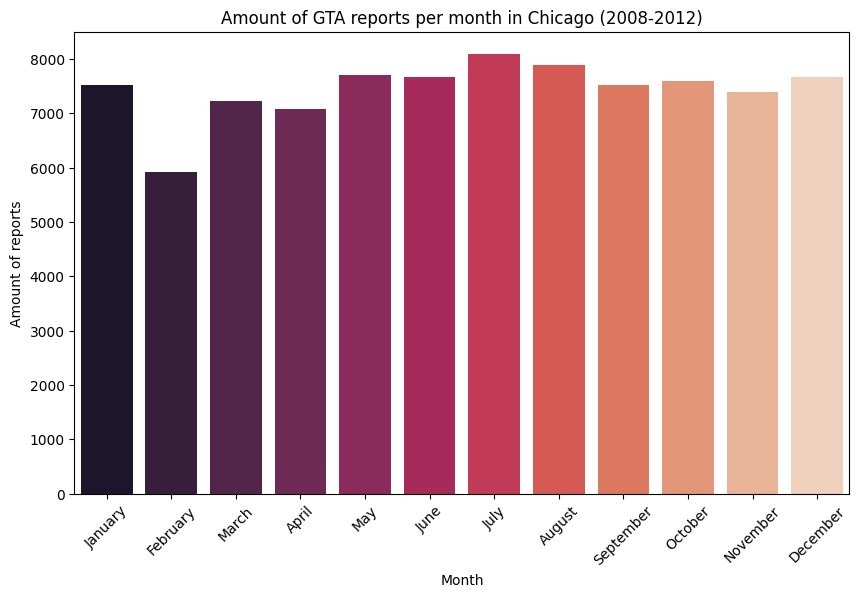

In [274]:
plt.figure(figsize=(10,6))
sns.barplot(data=chicago_GTA_2008_to_2012_monthplot_df, x="Month_name", y="Amount of reports", palette="rocket")
plt.title("Amount of GTA reports per month in Chicago (2008-2012)")
plt.xlabel("Month")
plt.ylabel("Amount of reports")
plt.xticks(rotation=45)
plt.show()

# 9. Just send me like location

https://www.youtube.com/watch?v=k7yBJ5Ffkdo

**9.1** Are there any (geographical) areas hit particularly hard by prostitution on friday nights?

**Svar: I choose to focus on the top 10 blocks of chicago that has been hit extra hard by prostitution on Friday nights. I printed all 10 of them out below.**
**But the block with the most amount of prostitution on friday nights is 021XX N CICERO AVE.**
**On the follow up question 9.2 when using latitude and longitude I choose to include all reports, because I wanted the full picture visualized. (kod nedan)**



In [275]:
chicago_prostitution_friday_night_df = chicago_crime_2008_to_2012_df[
    (chicago_crime_2008_to_2012_df["Primary Type"] == "PROSTITUTION") &
    (chicago_crime_2008_to_2012_df["Weekday"] == "Friday") &
    (chicago_crime_2008_to_2012_df["Time_of_day"]=="Nighttime")]


In [276]:
chicago_prostitution_friday_night_df = chicago_prostitution_friday_night_df.dropna(subset=["Latitude", "Longitude"])

In [277]:
chicago_prostitution_friday_night_block=chicago_prostitution_friday_night_df["Block"].value_counts().head(10)

In [278]:
chicago_prostitution_friday_night_block=chicago_prostitution_friday_night_block.reset_index(name = "Count") #Top10

In [279]:
chicago_prostitution_friday_night_block

,Block,Count
0,021XX N CICERO AVE,59
1,045XX W MADISON ST,46
2,046XX W MADISON ST,36
3,038XX W NORTH AVE,30
4,075XX S HALSTED ST,27
5,022XX S TROY ST,24
6,072XX S HALSTED ST,22
7,0000X N KENTON AVE,22
8,0000X S KENTON AVE,21
9,048XX S ASHLAND AVE,21


In [280]:
for b in chicago_prostitution_friday_night_block["Block"]:
    print(f"{b} is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.")

021XX N CICERO AVE is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
045XX W MADISON ST is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
046XX W MADISON ST is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
038XX W NORTH AVE is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
075XX S HALSTED ST is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
022XX S TROY ST is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
072XX S HALSTED ST is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
0000X N KENTON AVE is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
0000X S KENTON AVE is in the top 10 blocks of chicago hit extra hard by Prostitution on friday nights.
048XX S ASHLAND AVE is in the top 10 blocks of chicago hit extra hard by Pros

**9.2** Can you vizualise the locations from 9.1 on a map of Chicago? Is there a concentration somewhere? 

**Svar: There are plenty of concentrations. For example along the West Madison ST, West North AV and South Halsted ST. I choosed to include all prostitution reports in the interactive plot below. And alot of the top 10 that I presented above is obviously represented there. (kod och plot nedan)**

In [281]:
fig = px.density_mapbox(
    chicago_prostitution_friday_night_df,
    lat = "Latitude",
    lon = "Longitude",
    radius = 10,
    center = dict(lat=41.8781, lon=-87.6298),
    zoom = 10,
    mapbox_style="open-street-map",
    title="Friday night prostitution hotspots in Chicago"
)

fig.show()

**9.3*** Can you find any geographical concentration of other crime categories? Perhaps even by weekday and or day/nighttime? Plot these on a map of Chicago. 

**Svar: Ive plotted all homicides during daytime in chicago between 2008 and 2012.(Kod och plot nedan)**

In [282]:
chicago_homicide_daytime_df = chicago_crime_2008_to_2012_df[
    (chicago_crime_2008_to_2012_df["Primary Type"] == "HOMICIDE") &
    (chicago_crime_2008_to_2012_df["Time_of_day"]=="Daytime")]

In [283]:
chicago_homicide_daytime_df = chicago_homicide_daytime_df.dropna(subset=["Latitude","Longitude"])

In [284]:
chicago_homicide_daytime_df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Longitude,Location,Month,Month_name,Day,Hour,Weekday,Date only,Month_day,Time_of_day
287,20748,HV620483,2012-12-31 16:49:00,042XX W 21ST PL,0110,HOMICIDE,FIRST DEGREE MURDER,APARTMENT,True,True,...,-87.730687,"(41.85250485, -87.73068709)",12,December,31,16,Monday,2012-12-31,12-31,Daytime
976,20746,HV622070,2012-12-30 17:10:00,050XX S INDIANA AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,-87.621048,"(41.802908524, -87.62104831)",12,December,30,17,Sunday,2012-12-30,12-30,Daytime
1178,20745,HV621744,2012-12-30 11:00:00,005XX E 109TH ST,0110,HOMICIDE,FIRST DEGREE MURDER,ALLEY,False,False,...,-87.610533,"(41.69641053, -87.6105331)",12,December,30,11,Sunday,2012-12-30,12-30,Daytime
2079,20744,HV620483,2012-12-29 07:40:00,042XX W 21ST PL,0110,HOMICIDE,FIRST DEGREE MURDER,APARTMENT,True,True,...,-87.730687,"(41.85250485, -87.73068709)",12,December,29,7,Saturday,2012-12-29,12-29,Daytime
6239,20736,HV613856,2012-12-23 06:22:00,033XX W CRYSTAL ST,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,False,False,...,-87.709972,"(41.903722719, -87.709972333)",12,December,23,6,Sunday,2012-12-23,12-23,Daytime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1862929,4397,HP123802,2008-01-14 16:25:00,128XX S EGGLESTON AVE,0110,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,...,-87.632978,"(41.660066269, -87.632977522)",1,January,14,16,Monday,2008-01-14,01-14,Daytime
1872513,4382,HP101233,2008-01-06 14:18:00,024XX N MONTICELLO AVE,0110,HOMICIDE,FIRST DEGREE MURDER,HOUSE,True,False,...,-87.718230,"(41.925172259, -87.718230034)",1,January,6,14,Sunday,2008-01-06,01-06,Daytime
1872751,4388,HP108859,2008-01-06 08:19:00,047XX S ADA ST,0110,HOMICIDE,FIRST DEGREE MURDER,TAVERN,False,False,...,-87.658883,"(41.808230277, -87.658883267)",1,January,6,8,Sunday,2008-01-06,01-06,Daytime
1877513,4380,HP101233,2008-01-01 16:48:00,024XX N MONTICELLO AVE,0110,HOMICIDE,FIRST DEGREE MURDER,HOUSE,True,False,...,-87.718230,"(41.925172259, -87.718230034)",1,January,1,16,Tuesday,2008-01-01,01-01,Daytime


In [285]:
fig = px.density_mapbox(
    chicago_homicide_daytime_df,
    lat = "Latitude",
    lon = "Longitude",
    radius = 10,
    center = dict(lat=41.8781, lon=-87.6298),
    zoom = 10,
    mapbox_style="open-street-map",
    title="Homicides during daytime in Chicago 2008-2012 hotspots"
)

fig.show()

# 10 - The $ factor

**10.1** Merge the crime and census datasets together in a suitable way.

**Svar: (kod nedan)**

In [286]:
chicago_census_2008_to_2012_df

,Community Area Number,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX
0,1.0,Rogers Park,7.7,23.6,8.7,18.2,27.5,23939,39.0
1,2.0,West Ridge,7.8,17.2,8.8,20.8,38.5,23040,46.0
2,3.0,Uptown,3.8,24.0,8.9,11.8,22.2,35787,20.0
3,4.0,Lincoln Square,3.4,10.9,8.2,13.4,25.5,37524,17.0
4,5.0,North Center,0.3,7.5,5.2,4.5,26.2,57123,6.0
...,...,...,...,...,...,...,...,...,...
73,74.0,Mount Greenwood,1.0,3.4,8.7,4.3,36.8,34381,16.0
74,75.0,Morgan Park,0.8,13.2,15.0,10.8,40.3,27149,30.0
75,76.0,O'Hare,3.6,15.4,7.1,10.9,30.3,25828,24.0
76,77.0,Edgewater,4.1,18.2,9.2,9.7,23.8,33385,19.0


In [287]:
chicago_crime_2008_to_2012_df["Community Area"].value_counts()

Community Area
25.0    121746
43.0     63384
23.0     60267
8.0      59948
67.0     57139
         ...  
55.0      4123
12.0      3456
47.0      2809
9.0       1859
0.0         25
Name: count, Length: 78, dtype: int64

In [288]:
crime_df_clean = chicago_crime_2008_to_2012_df.dropna(subset=["Community Area"])
crime_df_clean = crime_df_clean[crime_df_clean["Community Area"] != 0]

community_df_clean = chicago_census_2008_to_2012_df.dropna(subset=["Community Area Number"])

In [289]:
community_df_clean["Community Area Number"] = pd.to_numeric(community_df_clean["Community Area Number"], errors = "coerce")
crime_df_clean["Community Area"] = pd.to_numeric(crime_df_clean["Community Area"], errors = "coerce")

In [290]:
merged_crime_census_df = crime_df_clean.merge(community_df_clean, left_on="Community Area", right_on = "Community Area Number", how = "inner")

In [291]:
merged_crime_census_df

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Time_of_day,Community Area Number,COMMUNITY AREA NAME,PERCENT OF HOUSING CROWDED,PERCENT HOUSEHOLDS BELOW POVERTY,PERCENT AGED 16+ UNEMPLOYED,PERCENT AGED 25+ WITHOUT HIGH SCHOOL DIPLOMA,PERCENT AGED UNDER 18 OR OVER 64,PER CAPITA INCOME,HARDSHIP INDEX
0,8953937,HW102973,2012-12-31 23:58:00,037XX N NORA AVE,0610,BURGLARY,FORCIBLE ENTRY,RESIDENCE-GARAGE,False,False,...,Nighttime,17.0,Dunning,5.2,10.6,10.0,16.2,33.6,26282,28.0
1,8950836,HW100039,2012-12-31 23:55:00,0000X E OHIO ST,2890,PUBLIC PEACE VIOLATION,OTHER VIOLATION,SIDEWALK,True,False,...,Nighttime,8.0,Near North Side,1.9,12.9,7.0,2.5,22.6,88669,1.0
2,8950918,HW100021,2012-12-31 23:55:00,035XX W MONTROSE AVE,0610,BURGLARY,FORCIBLE ENTRY,OTHER,False,False,...,Nighttime,16.0,Irving Park,6.3,13.1,10.0,22.4,31.6,27249,34.0
3,8954299,HW100700,2012-12-31 23:55:00,058XX S MARYLAND AVE,0890,THEFT,FROM BUILDING,HOSPITAL BUILDING/GROUNDS,False,False,...,Nighttime,41.0,Hyde Park,1.5,18.4,8.4,4.3,26.2,39056,14.0
4,8951459,HW100757,2012-12-31 23:50:00,028XX N HALSTED ST,0890,THEFT,FROM BUILDING,RESIDENCE,False,False,...,Nighttime,6.0,Lake View,1.1,11.4,4.7,2.6,17.0,60058,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878148,7300103,HS104010,2008-01-01 00:00:00,041XX N CICERO AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,GROCERY FOOD STORE,False,False,...,Nighttime,15.0,Portage Park,4.1,11.6,12.6,19.3,34.0,24336,35.0
1878149,7489476,HS292830,2008-01-01 00:00:00,017XX N LECLAIRE AVE,1753,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,True,...,Nighttime,25.0,Austin,6.3,28.6,22.6,24.4,37.9,15957,73.0
1878150,6877001,HR282821,2008-01-01 00:00:00,055XX S CORNELL AVE,0840,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,...,Nighttime,41.0,Hyde Park,1.5,18.4,8.4,4.3,26.2,39056,14.0
1878151,8294596,HT528529,2008-01-01 00:00:00,017XX E 67TH ST,1754,OFFENSE INVOLVING CHILDREN,AGG SEX ASSLT OF CHILD FAM MBR,RESIDENCE,False,True,...,Nighttime,43.0,South Shore,2.8,31.1,20.0,14.0,35.7,19398,55.0


**10.2*** Are there certain kinds of socoeconomic area that are more prone to certain kinds of crimes? Do a deep dive in the direction you fancy yourself here.

**Svar: Ive created 3 plots down below that represents the top 10 crimes based on Hardship index. Ive made 3 masks to seperate them based on the hardship index that every Community area has.**
**(High, medium and low)**
**In areas with "high" hardship index, we can see that narcotics is more common for example. While in areas with "low" hardship index theft is very common.**

In [292]:

high_hardship_index_mask = merged_crime_census_df["HARDSHIP INDEX"] >= 60
medium_hardship_index_mask = ((merged_crime_census_df["HARDSHIP INDEX"] < 60) & (merged_crime_census_df["HARDSHIP INDEX"] >= 40))
low_hardship_index_mask = merged_crime_census_df["HARDSHIP INDEX"] < 40

merged_crime_census_high_hardship_df = merged_crime_census_df[high_hardship_index_mask]
merged_crime_census_medium_hardship_df = merged_crime_census_df[medium_hardship_index_mask]
merged_crime_census_low_hardship_df = merged_crime_census_df[low_hardship_index_mask]

In [293]:
high_hardship_top10_count=merged_crime_census_high_hardship_df["Primary Type"].value_counts().reset_index(name="Amount of reports").head(10)

In [294]:
medium_hardship_top10_count=merged_crime_census_medium_hardship_df["Primary Type"].value_counts().reset_index(name="Amount of reports").head(10)

In [295]:
low_hardship_top10_count = merged_crime_census_low_hardship_df["Primary Type"].value_counts().reset_index(name="Amount of reports").head(10)

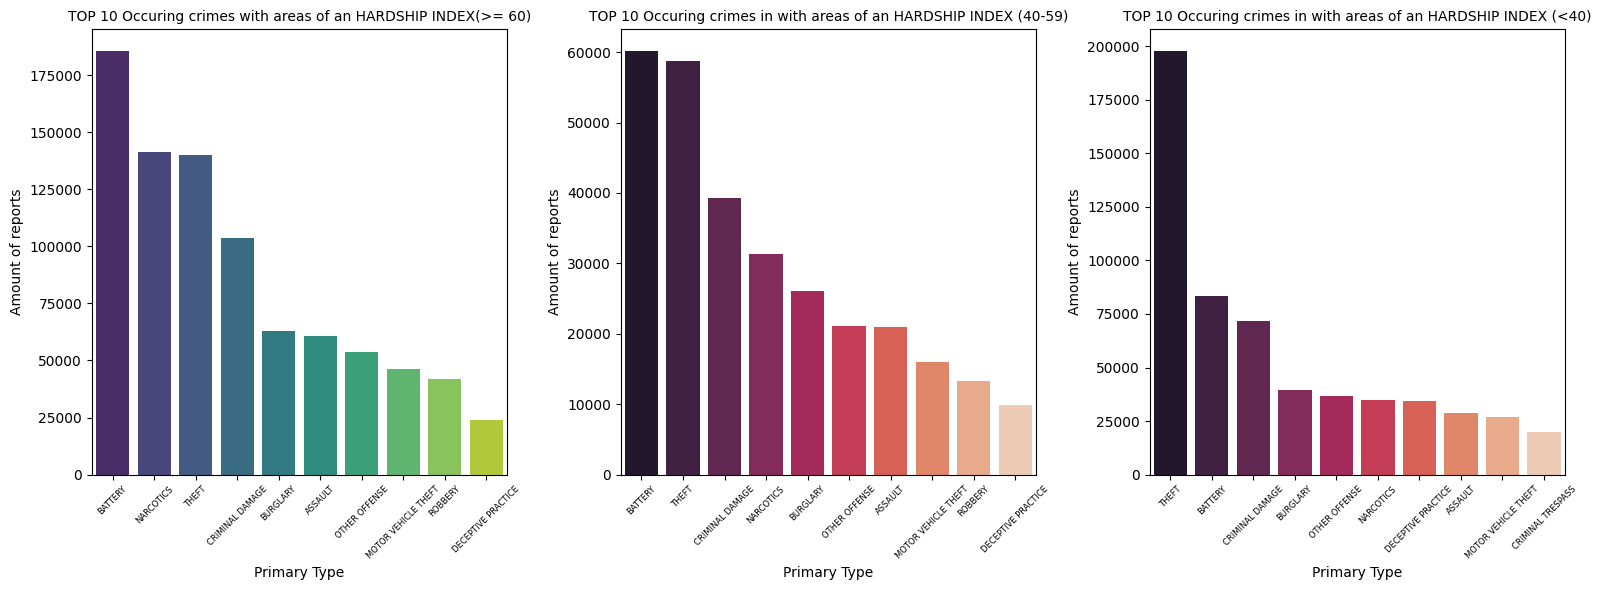

In [296]:
fig, axes = plt.subplots(1,3,figsize=(16,6))

sns.barplot(
    ax=axes[0],
    data=high_hardship_top10_count,
    x="Primary Type",
    y="Amount of reports",
    palette="viridis")
axes[0].set_title("TOP 10 Occuring crimes with areas of an HARDSHIP INDEX(>= 60)",fontsize=10)
axes[0].set_xlabel("Primary Type")
axes[0].set_ylabel("Amount of reports")
axes[0].tick_params(axis="x", rotation = 45,labelsize = 6)

sns.barplot(
    ax=axes[1],
    data=medium_hardship_top10_count,
    x="Primary Type",
    y="Amount of reports",
    palette="rocket")
axes[1].set_title("TOP 10 Occuring crimes in with areas of an HARDSHIP INDEX (40-59)",fontsize=10)
axes[1].set_xlabel("Primary Type")
axes[1].set_ylabel("Amount of reports")
axes[1].tick_params(axis="x", rotation = 45, labelsize = 6)

sns.barplot(
    ax=axes[2],
    data=low_hardship_top10_count,
    x="Primary Type",
    y="Amount of reports",
    palette="rocket")
axes[2].set_title("TOP 10 Occuring crimes in with areas of an HARDSHIP INDEX (<40)",fontsize=10)
axes[2].set_xlabel("Primary Type")
axes[2].set_ylabel("Amount of reports")
axes[2].tick_params(axis="x", rotation = 45, labelsize = 6)


plt.tight_layout()
plt.show()

# 11 - Your turn!

There are obviously so much more to gain by analysing these datasets. This is now your opportunity to dwelve deeper into what you yourself like.

    Instructions: think of one or several questions (as we've done above). Then, proceed with your own deep dive analysis and provide your answers.

*What Community Area has the most thefts? And where do they mostly take place(Location Description)*

**Svar: Near North Side is the Community Area with most thefts, they most often happen in the street. (kod nedan)**

In [297]:
theft_crime_mask = merged_crime_census_df["Primary Type"] == "THEFT"
merged_crime_census_theft_df = merged_crime_census_df[theft_crime_mask]

In [298]:
most_thefts = merged_crime_census_theft_df["COMMUNITY AREA NAME"].value_counts()

In [299]:
print(f"The Community Area with most thefts is {most_thefts.idxmax()} with {most_thefts.max()} thefts. (2008-2012) ")

The Community Area with most thefts is Near North Side with 26409 thefts. (2008-2012) 


In [300]:
North_side_mask = merged_crime_census_theft_df["COMMUNITY AREA NAME"] == "Near North Side"
merged_crime_census_theft_NNS_df = merged_crime_census_theft_df[North_side_mask]

In [301]:
location_mask = merged_crime_census_theft_NNS_df["Location Description"].value_counts()

In [302]:
print(f"In Near North Side, Theft is most likely to happen in the {location_mask.idxmax()}")

In Near North Side, Theft is most likely to happen in the STREET
